# EDA | Playing Cards Classification (53 classes)

**Objective:** To examine class distribution, image quality, image features, duplication, and reliability of the train/val/test split. The notebook **analyzes only** the data, does not modify the data, and does not resplitter the dataset. Each entry includes automated comments based on the actual data.

**Cấu trúc:** `notebooks/EDA.ipynb` · `data/raw/dataset.zip` · `data/metadata/{clean_metadata.csv,label_map.json,train.csv,val.csv,test.csv}`.

In [1]:
from pathlib import Path
from zipfile import ZipFile
from io import BytesIO
from collections import Counter
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

# Works when notebook is launched from notebooks/ or project root.
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the project root or notebooks/ directory")

RAW_DIR = ROOT / "data" / "raw"
METADATA_DIR = ROOT / "data" / "metadata"
ARCHIVE = RAW_DIR / "dataset.zip"
CLEAN_METADATA = METADATA_DIR / "clean_metadata.csv"
LABEL_MAP = METADATA_DIR / "label_map.json"
SPLIT_FILES = {s: METADATA_DIR / f"{s}.csv" for s in ("train", "val", "test")}

NUM_CLASSES = 53
SEED = 42
SAMPLE_FOR_PIXELS = 600
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for path in [ARCHIVE, CLEAN_METADATA, LABEL_MAP, *SPLIT_FILES.values()]:
    print(f"{'OK' if path.is_file() else 'MISSING':7} {path.relative_to(ROOT)}")
if not ARCHIVE.is_file():
    raise FileNotFoundError(ARCHIVE)

OK      data\raw\dataset.zip
OK      data\metadata\clean_metadata.csv
OK      data\metadata\label_map.json
OK      data\metadata\train.csv
OK      data\metadata\val.csv
OK      data\metadata\test.csv


## 1. Image Catalog and Labels

Read the file list from the ZIP. Prioritize `clean_metadata.csv` for labels; only infer from the parent directory if labels are missing. Keep `member` as the **path inside the ZIP**, not the path on the drive.

In [2]:
def normalized_path(s):
    return str(s).replace("\\", "/").removeprefix("./").strip("/")

SKIP_DIRS = {"train", "training", "val", "valid", "validation", "test", "testing", "images", "image", "dataset", "dataset_cleaned", "cards"}

def inferred_class(member):
    parts = Path(member).parts[:-1]
    options = [p for p in parts if p.lower() not in SKIP_DIRS and not p.startswith("__MACOSX")]
    return options[-1] if options else None

def inferred_split(member):
    aliases = {"train": "train", "training": "train", "val": "val", "valid": "val", "validation": "val", "test": "test", "testing": "test"}
    return next((aliases[p.lower()] for p in Path(member).parts[:-1] if p.lower() in aliases), None)

with ZipFile(ARCHIVE) as z:
    members = sorted(m for m in z.namelist() if not m.endswith("/") and Path(m).suffix.lower() in IMAGE_EXTS and "__MACOSX" not in Path(m).parts)

if not members:
    raise ValueError("ZIP contains no supported image files")
df = pd.DataFrame({"member": members})
df["extension"] = df.member.map(lambda m: Path(m).suffix.lower())
df["archive_split"] = df.member.map(inferred_split)
df["class_name"] = df.member.map(inferred_class)

if CLEAN_METADATA.is_file():
    meta = pd.read_csv(CLEAN_METADATA)
    print("clean_metadata.csv columns:", list(meta.columns))
    if {"member", "class_name"}.issubset(meta.columns):
        meta = meta.dropna(subset=["member"]).copy()
        meta["member"] = meta.member.map(normalized_path)
        duplicates = meta.groupby("member")["class_name"].nunique().gt(1).sum()
        print("Conflicting class labels in metadata:", duplicates)
        label_lookup = meta.drop_duplicates("member").set_index("member")["class_name"]
        df["class_name"] = df.member.map(label_lookup).fillna(df.class_name)
        print("Images matched to clean metadata:", df.member.isin(label_lookup.index).sum(), "/", len(df))
    else:
        print("Metadata lacks member/class_name; using folder labels")

print(f"Images: {len(df):,} | Classes: {df.class_name.nunique()} | Missing labels: {df.class_name.isna().sum()}")
print("File formats:", df.extension.value_counts().to_dict())
display(df.head())
if df.class_name.isna().any():
    display(df[df.class_name.isna()].head(10))
if df.class_name.nunique() != NUM_CLASSES:
    print(f"NOTICE: Expected {NUM_CLASSES} classes; found {df.class_name.nunique()}.")

clean_metadata.csv columns: ['member', 'class_name', 'class_id', 'split']
Conflicting class labels in metadata: 0
Images matched to clean metadata: 8077 / 8154
Images: 8,154 | Classes: 53 | Missing labels: 77
File formats: {'.jpg': 8154}


,member,extension,archive_split,class_name
0,dataset/ace of clubs 01.jpg,.jpg,None,ace of clubs
1,dataset/ace of clubs 02.jpg,.jpg,None,ace of clubs
2,dataset/ace of clubs 03.jpg,.jpg,None,NaN
3,dataset/ace of clubs 04.jpg,.jpg,None,ace of clubs
4,dataset/ace of clubs 05.jpg,.jpg,None,ace of clubs


,member,extension,archive_split,class_name
2,dataset/ace of clubs 03.jpg,.jpg,None,NaN
133,dataset/ace of diamonds 04.jpg,.jpg,None,NaN
417,dataset/ace of hearts 67.jpg,.jpg,None,NaN
941,dataset/eight of diamonds 83.jpg,.jpg,None,NaN
1353,dataset/five of clubs 28.jpg,.jpg,None,NaN
1358,dataset/five of clubs 33.jpg,.jpg,None,NaN
1378,dataset/five of clubs 53.jpg,.jpg,None,NaN
1379,dataset/five of clubs 54.jpg,.jpg,None,NaN
1454,dataset/five of diamonds 118.jpg,.jpg,None,NaN
1470,dataset/five of diamonds 132.jpg,.jpg,None,NaN


## 2. Class Distribution

Evaluate the number of images in each class and the disparity rate. A large disparity indicates poor overall accuracy and represents a class with fewer samples.

,images,share_%
class_name,,
ace of spades,191,2.34
ace of hearts,180,2.21
jack of spades,179,2.20
jack of hearts,178,2.18
jack of clubs,177,2.17
queen of diamonds,170,2.08
queen of clubs,169,2.07
seven of spades,169,2.07
eight of diamonds,168,2.06


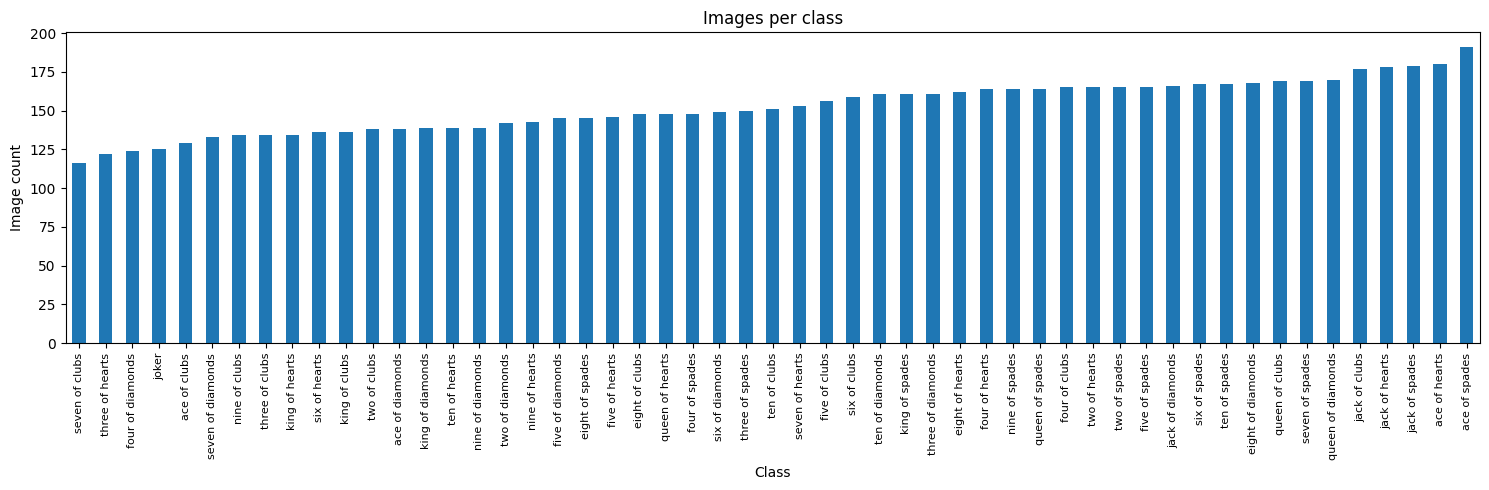

Range: 116–191 images/class | Max/min ratio: 1.65
Comment: Noticeable sample size difference; macro-F1 reporting and class recall required.


In [3]:
counts = df.class_name.value_counts().sort_values()
class_stats = pd.DataFrame({"images": counts, "share_%": (counts / len(df) * 100).round(2)})
display(class_stats.sort_values("images", ascending=False))
fig, ax = plt.subplots(figsize=(15, 5))
counts.plot.bar(ax=ax)
ax.set(title="Images per class", xlabel="Class", ylabel="Image count")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()
if len(counts):
    ratio = counts.max() / max(counts.min(), 1)
    print(f"Range: {counts.min()}–{counts.max()} images/class | Max/min ratio: {ratio:.2f}")
    print("Comment:", "Noticeable sample size difference; macro-F1 reporting and class recall required." if ratio > 1.5 else "Class distribution is relatively even across image sizes.")

## 3. Image Quality and Size

Check if the image is readable, its resolution, width/height ratio, and number of channels. An image might be in a ZIP file but be corrupted or not convertible to RGB.

Readable: 8,154/8,154 | Invalid: 0


,width,height,aspect_ratio,pixels
count,8154.0,8154.0,8154.0,8154.0
mean,224.0,224.0,1.0,50176.0
std,0.0,0.0,0.0,0.0
min,224.0,224.0,1.0,50176.0
25%,224.0,224.0,1.0,50176.0
50%,224.0,224.0,1.0,50176.0
75%,224.0,224.0,1.0,50176.0
max,224.0,224.0,1.0,50176.0


Color modes: {'RGB': 8154}


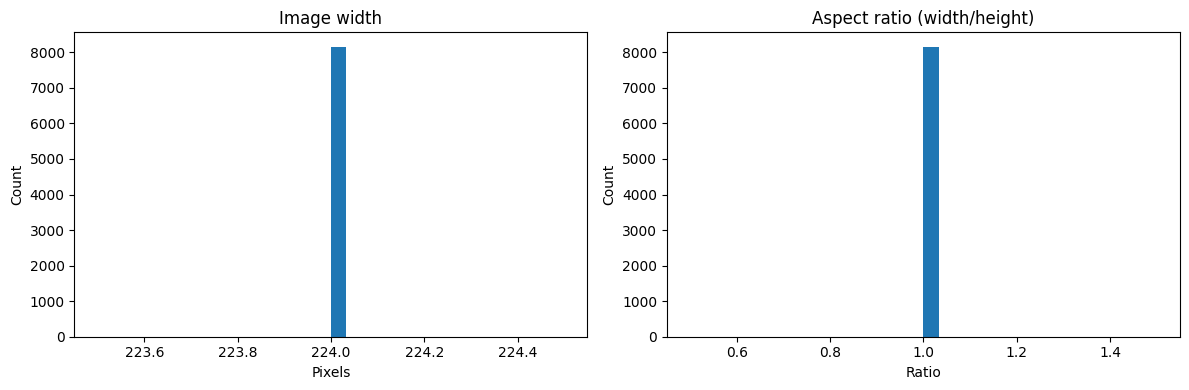

Most common resolutions:


,,images
width,height,
224,224,8154


Comment: Images have the same resolution; the resizing step must still be consistent across models.


In [4]:
records = []
with ZipFile(ARCHIVE) as z:
    for member in df.member:
        try:
            with Image.open(BytesIO(z.read(member))) as im:
                im.load()
                width, height, mode = im.width, im.height, im.mode
            records.append((member, width, height, mode, None))
        except Exception as exc:
            records.append((member, np.nan, np.nan, None, type(exc).__name__))
quality = pd.DataFrame(records, columns=["member", "width", "height", "mode", "error"])
df = df.merge(quality, on="member", how="left", validate="one_to_one")
valid = df[df.error.isna()].copy()
valid["aspect_ratio"] = valid.width / valid.height
valid["pixels"] = valid.width * valid.height
print(f"Readable: {len(valid):,}/{len(df):,} | Invalid: {df.error.notna().sum()}")
display(valid[["width", "height", "aspect_ratio", "pixels"]].describe().round(2))
print("Color modes:", valid["mode"].value_counts().to_dict())
if df.error.notna().any():
    display(df.loc[df.error.notna(), ["member", "error"]].head(15))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid.width, bins=30)
axes[0].set(title="Image width", xlabel="Pixels", ylabel="Count")
axes[1].hist(valid.aspect_ratio, bins=30)
axes[1].set(title="Aspect ratio (width/height)", xlabel="Ratio", ylabel="Count")
plt.tight_layout()
plt.show()
size_variants = valid.groupby(["width", "height"]).size().sort_values(ascending=False)
print("Most common resolutions:")
display(size_variants.head(10).rename("images").to_frame())
print("Comment:", "Images have multiple sizes/scales; consistent resizing is required during training." if len(size_variants) > 1 else "Images have the same resolution; the resizing step must still be consistent across models.")

## 4. Sample Images by Layer

Observe the background color, card position, rotation angle, sharpness, and easily confused layers. Display a random image of up to 18 layers to keep the notebook from becoming too long.

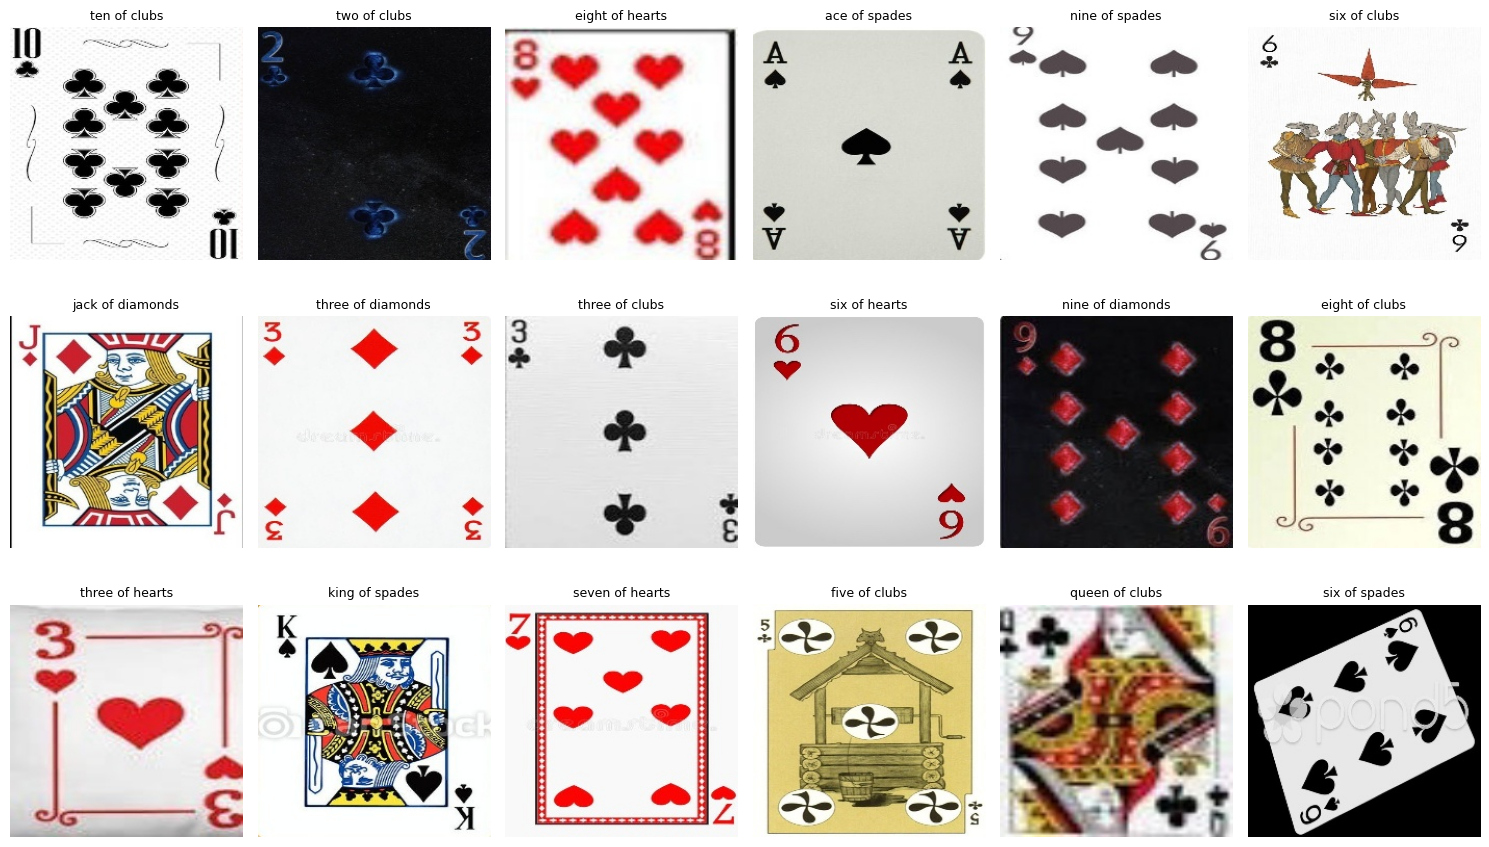

Comment: Visual observation helps determine the background image, the angle of the artwork, and the level of diversity within each class; this is a qualitative assessment and does not infer the accuracy of the model.


In [5]:
rng = np.random.default_rng(SEED)
classes = sorted(valid.class_name.dropna().unique())
selected_classes = rng.choice(classes, size=min(18, len(classes)), replace=False) if classes else []
fig, axes = plt.subplots(3, 6, figsize=(15, 9))
with ZipFile(ARCHIVE) as z:
    for ax, cls in zip(axes.flat, selected_classes):
        member = valid.loc[valid.class_name == cls, "member"].sample(1, random_state=SEED).iloc[0]
        with Image.open(BytesIO(z.read(member))) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(str(cls), fontsize=9)
    for ax in axes.flat:
        ax.axis("off")
plt.tight_layout()
plt.show()
print("Comment: Visual observation helps determine the background image, the angle of the artwork, and the level of diversity within each class; this is a qualitative assessment and does not infer the accuracy of the model.")

## 5. Color, Brightness, and Contrast

Limited sampling is used to avoid the cost of reading every pixel. RGB statistics on the image are converted to RGB and resized to 64×64; brightness and contrast are calculated from the grayscale image.

,R,G,B,brightness,contrast
count,600.000,600.000,600.000,600.000,600.000
mean,0.764,0.712,0.684,0.725,0.235
std,0.198,0.198,0.209,0.196,0.077
min,0.081,0.003,0.004,0.030,0.065
25%,0.714,0.663,0.600,0.677,0.178
50%,0.814,0.763,0.737,0.778,0.233
75%,0.891,0.836,0.831,0.851,0.292
max,0.989,0.960,0.960,0.962,0.466


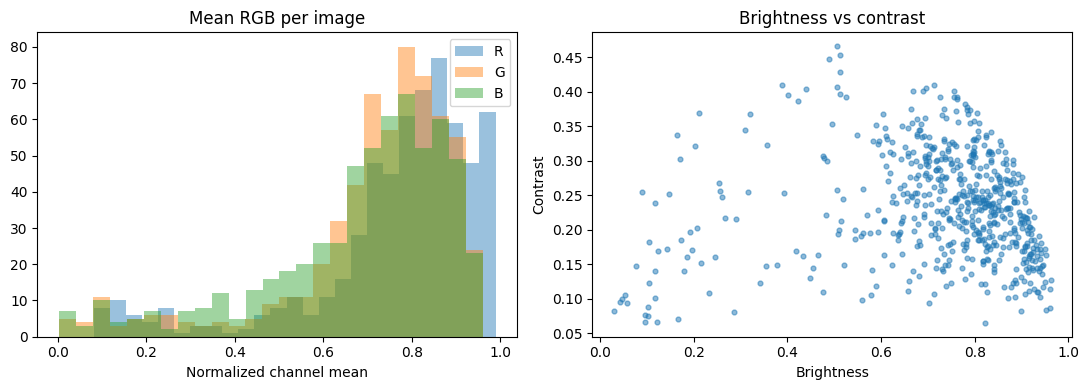

Comment: Average brightness 0.725, standard deviation between images 0.195. Descriptive statistics of image sample 600, not the entire dataset.


In [10]:
sample = valid.sample(n=min(SAMPLE_FOR_PIXELS, len(valid)), random_state=SEED)
colors, brightness, contrast = [], [], []
with ZipFile(ARCHIVE) as z:
    for member in sample.member:
        with Image.open(BytesIO(z.read(member))) as im:
            rgb = np.asarray(im.convert("RGB").resize((64, 64)), dtype=np.float32) / 255.0
        colors.append(rgb.mean(axis=(0, 1)))
        gray = rgb @ np.array([0.299, 0.587, 0.114])
        brightness.append(gray.mean())
        contrast.append(gray.std())
colors = np.asarray(colors)
pixel_stats = pd.DataFrame(colors, columns=["R", "G", "B"])
pixel_stats["brightness"] = brightness
pixel_stats["contrast"] = contrast
display(pixel_stats.describe().round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for channel in ("R", "G", "B"):
    axes[0].hist(pixel_stats[channel], bins=25, alpha=.45, label=channel)
axes[0].set(title="Mean RGB per image", xlabel="Normalized channel mean")
axes[0].legend()
axes[1].scatter(brightness, contrast, s=12, alpha=.5)
axes[1].set(title="Brightness vs contrast", xlabel="Brightness", ylabel="Contrast")
plt.tight_layout()
plt.show()
print(f"Comment: Average brightness {np.mean(brightness):.3f}, standard deviation between images {np.std(brightness):.3f}. Descriptive statistics of image sample {len(sample)}, not the entire dataset.")

## 6. Exactly Matching Images and Label Conflicts

SHA-256 searches for **byte-identical** files. Two images that look similar but have different compression/trimming/rotation may not have the same hash; therefore, this step **does not** detect near-duplicates.

In [7]:
hashes = {}
with ZipFile(ARCHIVE) as z:
    for member in df.member:
        hashes[member] = hashlib.sha256(z.read(member)).hexdigest()
df["sha256"] = df.member.map(hashes)
dup_groups = df.groupby("sha256").size()
duplicate_hashes = dup_groups[dup_groups > 1].index
duplicate_rows = df[df.sha256.isin(duplicate_hashes)].sort_values("sha256")
conflicting_hashes = df.groupby("sha256").class_name.nunique(dropna=True)
conflicting_hashes = conflicting_hashes[conflicting_hashes > 1].index
print("Exact duplicate groups:", len(duplicate_hashes))
print("Extra duplicate files:", int((dup_groups - 1).clip(lower=0).sum()))
print("Hashes with conflicting labels:", len(conflicting_hashes))
if not duplicate_rows.empty:
    display(duplicate_rows[["member", "class_name", "sha256"]].head(20))
print("Comment:", "Duplicate bytes are found; the allocation to sets needs to be checked before training." if len(duplicate_hashes) else "No duplicate bytes found; near duplicate images cannot be eliminated yet.")

Exact duplicate groups: 2
Extra duplicate files: 2
Hashes with conflicting labels: 0


,member,class_name,sha256
7245,dataset/three of diamonds 79.jpg,three of diamonds,7c4e0521bc13e6770126e47021a1f64b27e93a4d93570a...
7246,dataset/three of diamonds 80.jpg,NaN,7c4e0521bc13e6770126e47021a1f64b27e93a4d93570a...
1926,dataset/four of clubs 127.jpg,NaN,b862d1b05361e9e3d5a2b03f668a2db87d0beb6e88362b...
2374,dataset/four of spades 120.jpg,NaN,b862d1b05361e9e3d5a2b03f668a2db87d0beb6e88362b...


Comment: Duplicate bytes are found; the allocation to sets needs to be checked before training.


## 7. Check train/validation/test

Read all three CSV splits correctly. Verify that image names match the ZIP codes, images are located in multiple splits, class distribution is consistent across splits, and hashes match between splits. Do not automatically create new splits or delete images.

train.csv rows: 5653 columns: ['member', 'class_name', 'class_id', 'split']
val.csv rows: 1212 columns: ['member', 'class_name', 'class_id', 'split']
test.csv rows: 1212 columns: ['member', 'class_name', 'class_id', 'split']
Members assigned to multiple splits: 0
CSV members missing from ZIP: 0
Duplicate member rows in split files: 0
ZIP members without CSV assignment: 77


,images,share_%
split,,
train,5653,69.99
val,1212,15.01
test,1212,15.01


split,train,val,test
class_name,,,
ace of clubs,90,20,19
ace of diamonds,97,21,20
ace of hearts,126,27,27
ace of spades,134,29,28
eight of clubs,104,22,22
eight of diamonds,118,25,25
eight of hearts,113,24,25
eight of spades,101,22,22
five of clubs,109,23,24


Classes missing in at least one split: 0


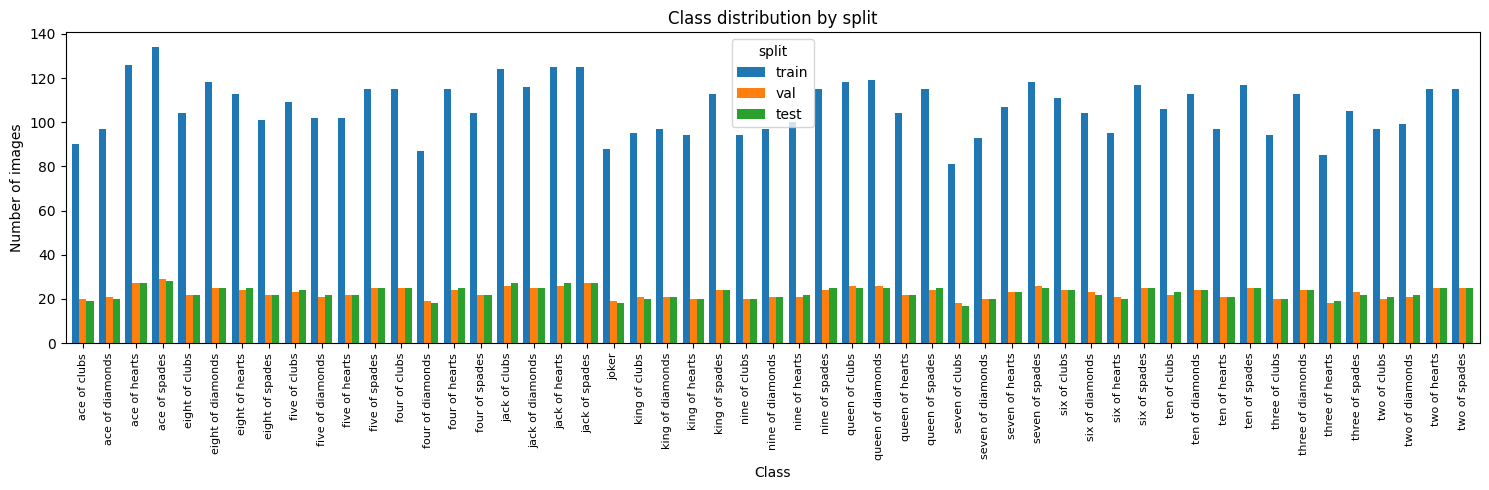

Exact duplicate hashes across splits: 0
Comment: No byte overlap found between assigned splits; near-duplicate leakage has not been checked.


In [8]:
parts = []
for split_name, path in SPLIT_FILES.items():
    if not path.is_file():
        print("Missing split file:", path.name)
        continue
    part = pd.read_csv(path)
    print(path.name, "rows:", len(part), "columns:", list(part.columns))
    if "member" not in part:
        print("  Skipped: member column not found")
        continue
    p = part[["member"]].dropna().copy()
    p["member"] = p.member.map(normalized_path)
    p["split"] = split_name
    parts.append(p)

split_df = df[["member", "class_name", "sha256", "archive_split"]].copy()
split_df["split"] = split_df.archive_split
if parts:
    assignments = pd.concat(parts, ignore_index=True)
    conflicting_members = assignments.groupby("member").split.nunique()
    print("Members assigned to multiple splits:", int((conflicting_members > 1).sum()))
    missing_members = set(assignments.member) - set(df.member)
    print("CSV members missing from ZIP:", len(missing_members))
    print("Duplicate member rows in split files:", int(assignments.duplicated(["member", "split"]).sum()))
    assigned = assignments.drop_duplicates("member").set_index("member").split
    split_df["split"] = split_df.member.map(assigned).fillna(split_df.archive_split)
    print("ZIP members without CSV assignment:", int((~df.member.isin(assigned.index)).sum()))
    if missing_members:
        print("Example missing paths:", sorted(missing_members)[:5])
else:
    print("No usable CSV splits: using folder information if available")

known = split_df[split_df.split.isin(["train", "val", "test"])].copy()
if known.empty:
    print("No usable split assignments; cannot audit cross-split leakage")
else:
    summary = known.split.value_counts().reindex(["train", "val", "test"], fill_value=0)
    display(pd.DataFrame({"images": summary, "share_%": (summary / len(known) * 100).round(2)}))
    class_table = pd.crosstab(known.class_name, known.split).reindex(columns=["train", "val", "test"], fill_value=0)
    display(class_table)
    print("Classes missing in at least one split:", int((class_table == 0).any(axis=1).sum()))
    ax = class_table.plot.bar(figsize=(15, 5), width=.8, title="Class distribution by split")
    ax.set(xlabel="Class", ylabel="Number of images")
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()
    cross_hash = known.groupby("sha256").split.nunique()
    leaked_hashes = cross_hash[cross_hash > 1].index
    print("Exact duplicate hashes across splits:", len(leaked_hashes))
    if len(leaked_hashes):
        display(known[known.sha256.isin(leaked_hashes)].sort_values("sha256").head(20))
    print("Comment:", "Exact data leakage exists between splits; metric test/validation is at risk of being blown." if len(leaked_hashes) else "No byte overlap found between assigned splits; near-duplicate leakage has not been checked.")

## 8. EDA Summary

Conclusions are drawn from the actual results of previous cells; clearly distinguish between issues that have been verified and issues that require further investigation. Do not conclude that the model is overfitted or performs well based solely on EDA.

In [9]:
notes = [
    f"Dataset: **{len(df):,} image file**, **{df.class_name.nunique()} class** (expect {NUM_CLASSES}).",
    f"File quality: **{df.error.notna().sum()}** image files could not be read; **{len(size_variants)}** different resolutions.",
    f"Class balance: at least **{counts.min()}**, at most **{counts.max()}** images/class; max/min ratio **{counts.max()/max(counts.min(), 1):.2f}**.",
    f"Duplicate bytes: **{len(duplicate_hashes)}** SHA-256 groups are duplicates; **{len(conflicting_hashes)}** hashes have inconsistent labels.",
]
if known.empty:
    notes.append("Split: No valid split information is available to confirm data leakage.")
else:
    notes.append(f"Split: **{len(known):,}** image files have split labels; **{len(leaked_hashes)}** hashes are duplicated across splits.")
notes.append("Limitations: SHA-256 does not detect near-duplicates; RGB analysis is based on sample images rather than the entire dataset.")
display(Markdown("### Tóm tắt kết quả\n" + "\n".join(f"- {note}" for note in notes)))

### Tóm tắt kết quả
- Dataset: **8,154 image file**, **53 class** (expect 53).
- File quality: **0** image files could not be read; **1** different resolutions.
- Class balance: at least **116**, at most **191** images/class; max/min ratio **1.65**.
- Duplicate bytes: **2** SHA-256 groups are duplicates; **0** hashes have inconsistent labels.
- Split: **8,077** image files have split labels; **0** hashes are duplicated across splits.
- Limitations: SHA-256 does not detect near-duplicates; RGB analysis is based on sample images rather than the entire dataset.